In [171]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

In [172]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [173]:
df.head(5)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


In [174]:
df.shape

(19402, 4)

In [175]:
df.columns.tolist()

['entity', 'code', 'year', 'fertility_rate_hist']

In [176]:
df.dtypes

entity                     str
code                       str
year                     int64
fertility_rate_hist    float64
dtype: object

In [177]:
df.tail()

,entity,code,year,fertility_rate_hist
19397,Zimbabwe,ZWE,2019,3.748
19398,Zimbabwe,ZWE,2020,3.754
19399,Zimbabwe,ZWE,2021,3.765
19400,Zimbabwe,ZWE,2022,3.767
19401,Zimbabwe,ZWE,2023,3.724


In [178]:
mexico = df[df['entity'] == 'Mexico']
japon = df[df['entity'] == 'Japan']
print(mexico.shape)
print(japon.shape)

(74, 4)
(77, 4)


In [179]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

print(anios_mexico)
print(tasa_mexico)
print(anios_japon)
print(tasa_japon)

[1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023]
[6.709 6.727 6.731 6.734 6.745 6.73  6.743 6.752 6.758 6.758 6.763 6.777
 6.8   6.817 6.833 6.819 6.79  6.753 6.707 6.626 6.529 6.419 6.281 6.121
 5.947 5.739 5.543 5.361 5.202 4.964 4.739 4.574 4.425 4.296 4.184 4.087
 3.971 3.803 3.64  3.532 3.444 3.363 3.285 3.211 3.132 3.044 2.964 2.886
 2.815 2.763 2.714 2.671 2.633 2.579 2.536 2.495 2.456 2.421 2.391 2.364
 2.34  2.317 2.294 2.269 2.211 2.137 2.086 2.041 2.03  2.02  1.99  1.97
 1.94  1.91 ]
[1947 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960
 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980

In [180]:
type(mexico)

pandas.DataFrame

In [181]:
type(anios_mexico)

numpy.ndarray

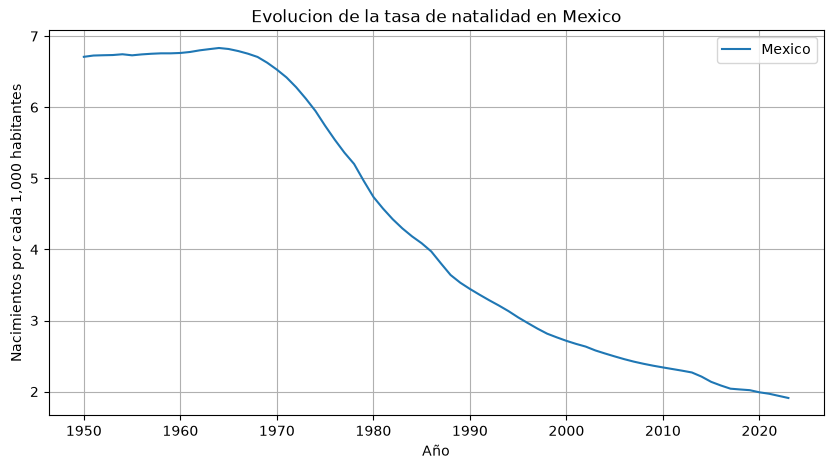

In [182]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="Mexico",
)

plt.title("Evolucion de la tasa de natalidad en Mexico")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

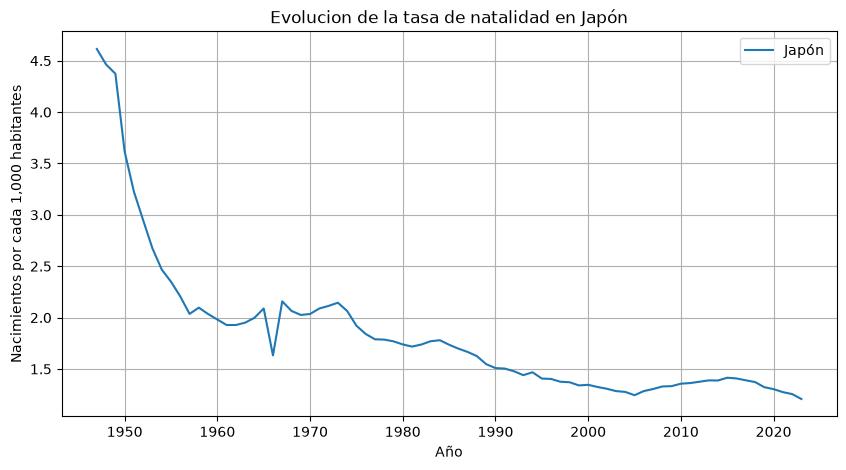

In [183]:
plt.figure(figsize=(10, 5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón",
)

plt.title("Evolucion de la tasa de natalidad en Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

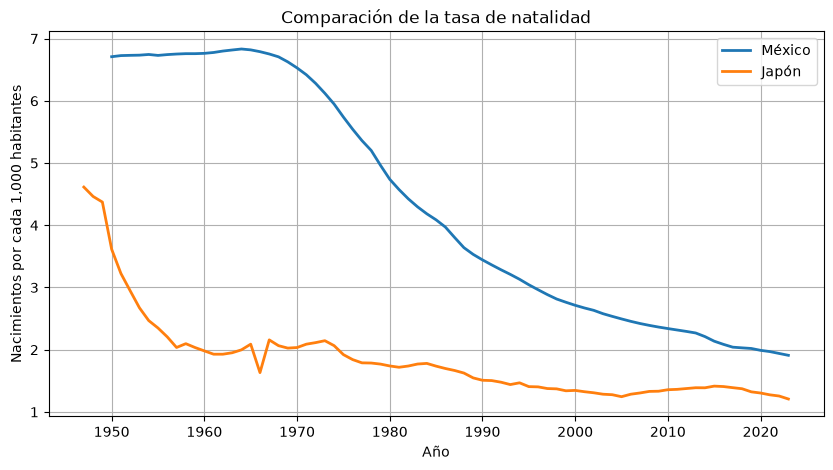

In [184]:
plt.figure(figsize=(10, 5))

plt.plot(anios_mexico, tasa_mexico, label="México", linewidth=2)
plt.plot(anios_japon, tasa_japon, label="Japón", linewidth=2)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [185]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
print(mascara_coincidencia_anios)

[False False False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]


In [186]:
anios_japon = anios_japon[mascara_coincidencia_anios]
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [187]:
anios_japon.shape

(74,)

In [188]:
diferencia = tasa_mexico - tasa_japon
diferencia

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

In [189]:
tasa_japon.shape

(74,)

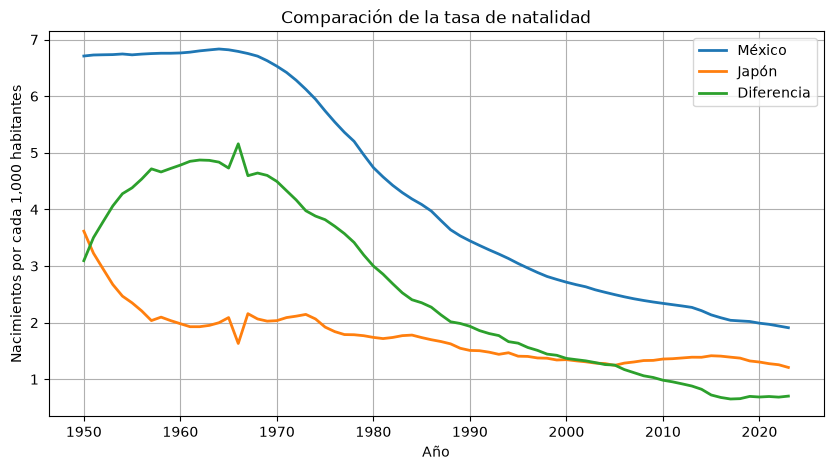

In [190]:
plt.figure(figsize=(10, 5))

plt.plot(anios_mexico, tasa_mexico, label="México", linewidth=2)
plt.plot(anios_japon, tasa_japon, label="Japón", linewidth=2)
plt.plot(anios_mexico, diferencia, label="Diferencia", linewidth=2)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [191]:
anios_comunes = np.intersect1d(anios_mexico, anios_japon)

In [192]:
len(anios_comunes)

74

In [193]:
type(anios_comunes)

numpy.ndarray

In [194]:
print(anios_japon[30])

1980


In [195]:
anios_japon = np.delete(anios_japon, [30, 42, 48])

In [196]:
mexico.head(3)

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731


In [197]:
japon.head(3)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373


In [198]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [199]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [200]:
comparacion_mexico_japon["diferencia"] = (
    comparacion_mexico_japon["fertility_rate_hist_mexico"] - comparacion_mexico_japon["fertility_rate_hist_japon"]
)

<Figure size 1000x500 with 0 Axes>

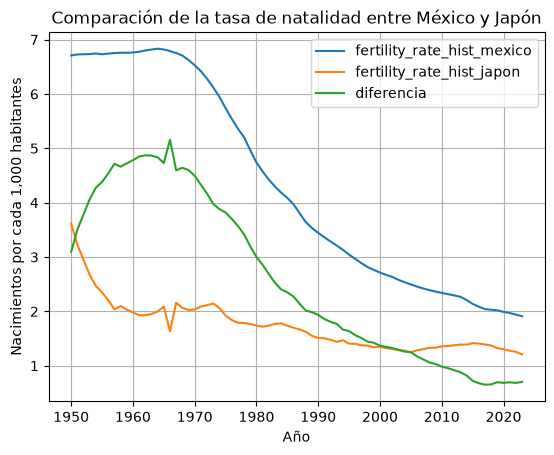

In [201]:
plt.figure(figsize=(10, 5))

comparacion_mexico_japon.plot(
    x="year",
    y=["fertility_rate_hist_mexico", "fertility_rate_hist_japon", "diferencia"],
    kind="line",
)

plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.title("Comparación de la tasa de natalidad entre México y Japón")
plt.grid(True)
plt.legend()